# Olist E-Commerce Data Analysis Using Python
## Project Overview

This project analyzes Olist e-commerce data using Python to understand
sales performance, customer behavior, payment methods, and delivery performance.

## Dataset and Tools

### Dataset
Olist Brazilian E-Commerce Public Dataset

### Tools Used
- Python
- Pandas
- Matplotlib
- Jupyter Notebook

### Analysis Areas
- Order trends
- Delivery performance
- Sales and freight
- Seller performance
- Payment methods
- Customer locations
- Customer reviews

## 1. Data Loading and Preparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Python environment is ready!")
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)

Python environment is ready!
Pandas version: 3.0.6
NumPy version: 2.5.3


In [2]:
import os
files = os.listdir()
print("Files in this Python folder:")
for file in files:
    print(files)

Files in this Python folder:
['.ipynb_checkpoints', 'olist_customers_dataset.csv', 'olist_geolocation_dataset.csv', 'olist_orders_dataset.csv', 'olist_order_items_dataset.csv', 'olist_order_payments_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_products_dataset.csv', 'Olist_Python_Analysis.ipynb', 'olist_sellers_dataset.csv', 'product_category_name_translation.csv']
['.ipynb_checkpoints', 'olist_customers_dataset.csv', 'olist_geolocation_dataset.csv', 'olist_orders_dataset.csv', 'olist_order_items_dataset.csv', 'olist_order_payments_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_products_dataset.csv', 'Olist_Python_Analysis.ipynb', 'olist_sellers_dataset.csv', 'product_category_name_translation.csv']
['.ipynb_checkpoints', 'olist_customers_dataset.csv', 'olist_geolocation_dataset.csv', 'olist_orders_dataset.csv', 'olist_order_items_dataset.csv', 'olist_order_payments_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_products_dataset.csv', 'Olist_Python_Analysis

## 2. Order Analysis

In [3]:
orders = pd.read_csv("olist_orders_dataset.csv")
print("Rows:", orders.shape[0])
print("Column:", orders.shape[1])
orders.head()

Rows: 99441
Column: 8


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,10/2/2017 10:56,10/2/2017 11:07,10/4/2017 19:55,10/10/2017 21:25,10/18/2017 0:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,7/24/2018 20:41,7/26/2018 3:24,7/26/2018 14:31,8/7/2018 15:27,8/13/2018 0:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,8/8/2018 8:38,8/8/2018 8:55,8/8/2018 13:50,8/17/2018 18:06,9/4/2018 0:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,11/18/2017 19:28,11/18/2017 19:45,11/22/2017 13:39,12/2/2017 0:28,12/15/2017 0:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2/13/2018 21:18,2/13/2018 22:20,2/14/2018 19:46,2/16/2018 18:17,2/26/2018 0:00


In [4]:
print("Column names:")
print("\nData types:")
print(orders.dtypes)

Column names:

Data types:
order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object


In [5]:
date_columns = ["order_purchase_timestamp", "order_approved_at", "order_delivered_carrier_date", "order_delivered_customer_date", "order_estimated_delivery_date"]
for col in date_columns: 
    orders[col] = pd.to_datetime(orders[col], errors="coerce")
    print(orders[date_columns].dtypes)

order_purchase_timestamp         datetime64[us]
order_approved_at                           str
order_delivered_carrier_date                str
order_delivered_customer_date               str
order_estimated_delivery_date               str
dtype: object
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date                str
order_delivered_customer_date               str
order_estimated_delivery_date               str
dtype: object
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date               str
order_estimated_delivery_date               str
dtype: object
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date               st

In [6]:
missing_values = orders.isnull().sum()
print("Missing values in orders dataset:")
print(missing_values)

Missing values in orders dataset:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64


In [7]:
status_counts = orders["order_status"].value_counts()
print("Order Status Distribution:")
print(status_counts)

Order Status Distribution:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


In [8]:
status_summary = orders["order_status"].value_counts().reset_index()
status_summary.columns = ["order_status", "order_count"]
status_summary["percentage"] = (status_summary["order_count"] / len(orders)*100).round(2)
status_summary

,order_status,order_count,percentage
0,delivered,96478,97.02
1,shipped,1107,1.11
2,canceled,625,0.63
3,unavailable,609,0.61
4,invoiced,314,0.32
5,processing,301,0.30
6,created,5,0.01
7,approved,2,0.00


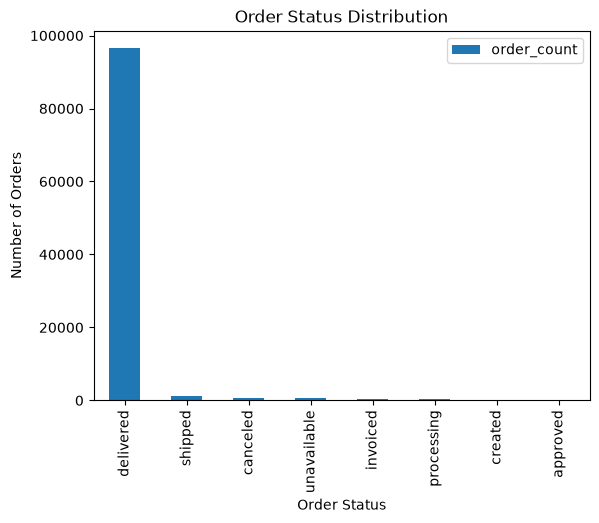

In [9]:
status_summary.plot(
    x= "order_status",
    y= "order_count",
    kind = "bar")
plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.show()

In [10]:
orders["month"] = orders["order_purchase_timestamp"].dt.to_period("M")
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:00,2017-10-02 11:07:00,2017-10-04 19:55:00,2017-10-10 21:25:00,2017-10-18,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:00,2018-07-26 03:24:00,2018-07-26 14:31:00,2018-08-07 15:27:00,2018-08-13,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:00,2018-08-08 08:55:00,2018-08-08 13:50:00,2018-08-17 18:06:00,2018-09-04,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:00,2017-11-18 19:45:00,2017-11-22 13:39:00,2017-12-02 00:28:00,2017-12-15,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:00,2018-02-13 22:20:00,2018-02-14 19:46:00,2018-02-16 18:17:00,2018-02-26,2018-02


In [11]:
orders["month"].value_counts().sort_index()

month
2016-09       4
2016-10     324
2016-12       1
2017-01     800
2017-02    1780
2017-03    2682
2017-04    2404
2017-05    3700
2017-06    3245
2017-07    4026
2017-08    4331
2017-09    4285
2017-10    4631
2017-11    7544
2017-12    5673
2018-01    7269
2018-02    6728
2018-03    7211
2018-04    6939
2018-05    6873
2018-06    6167
2018-07    6292
2018-08    6512
2018-09      16
2018-10       4
Freq: M, Name: count, dtype: int64

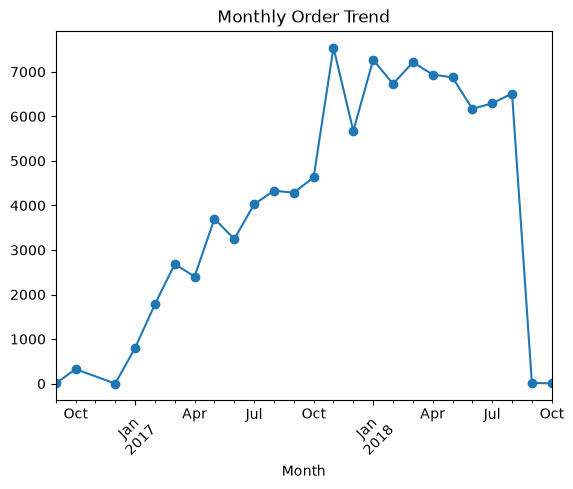

In [12]:
import matplotlib.pyplot as plt
monthly_orders = orders["month"].value_counts().sort_index()
monthly_orders.plot(kind="line",marker="o")
plt.title("Monthly Order Trend")
plt.xlabel("Month")
plt.xticks(rotation=45)
plt.show()

In [13]:
orders.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'month'],
      dtype='str')

## 3. Delivery Performance Analysis

In [14]:
orders["delivery_days"]= (orders["order_delivered_customer_date"] - orders["order_purchase_timestamp"]).dt.days
orders[["order_purchase_timestamp", "order_delivered_customer_date","delivery_days"]].head()

,order_purchase_timestamp,order_delivered_customer_date,delivery_days
0,2017-10-02 10:56:00,2017-10-10 21:25:00,8.0
1,2018-07-24 20:41:00,2018-08-07 15:27:00,13.0
2,2018-08-08 08:38:00,2018-08-17 18:06:00,9.0
3,2017-11-18 19:28:00,2017-12-02 00:28:00,13.0
4,2018-02-13 21:18:00,2018-02-16 18:17:00,2.0


In [15]:
orders["delivery_difference"] = (
    orders["order_delivered_customer_date"] - orders["order_estimated_delivery_date"]).dt.days
orders[["order_delivered_customer_date",
        "order_estimated_delivery_date",
        "delivery_difference"]].head()

,order_delivered_customer_date,order_estimated_delivery_date,delivery_difference
0,2017-10-10 21:25:00,2017-10-18,-8.0
1,2018-08-07 15:27:00,2018-08-13,-6.0
2,2018-08-17 18:06:00,2018-09-04,-18.0
3,2017-12-02 00:28:00,2017-12-15,-13.0
4,2018-02-16 18:17:00,2018-02-26,-10.0


In [16]:
delivered_orders = orders[orders["order_status"] == "delivered"].copy()

print("Total Delivered Orders:", len(delivered_orders))

Total Delivered Orders: 96478


In [17]:
delivered_orders["delivery_difference"] = (delivered_orders["order_delivered_customer_date"]-
                                           delivered_orders["order_estimated_delivery_date"]).dt.days
delivered_orders["delivery_performance"] = delivered_orders["delivery_difference"].apply(
    lambda x: "Early" if x <0 else ("On Time" if x==0 else "Late"))
delivered_orders["delivery_performance"].value_counts()

delivery_performance
Early      88644
Late        6542
On Time     1292
Name: count, dtype: int64

In [18]:
print("Total orders:",len(orders))
print("Delivered orders:", len(delivered_orders))

Total orders: 99441
Delivered orders: 96478


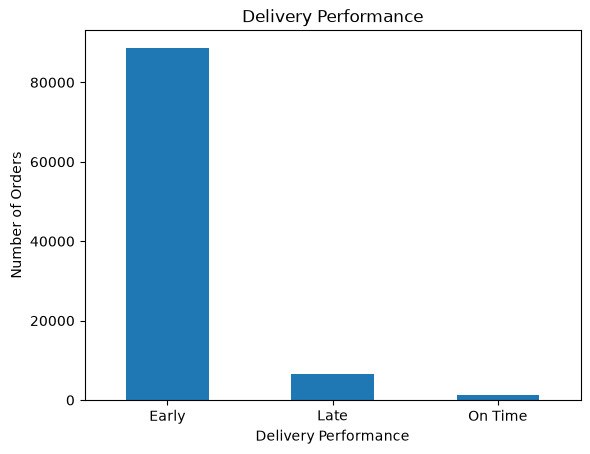

In [19]:
delivery_counts= delivered_orders["delivery_performance"].value_counts()
delivery_counts.plot(kind="bar")
plt.title("Delivery Performance")
plt.xlabel("Delivery Performance")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.show()

In [20]:
late_orders = delivered_orders[delivered_orders["delivery_difference"]>0]
print("Late Orders:", len(late_orders))
print("Avereage Days Late:", late_orders["delivery_difference"].mean())
print("Maximum Days Late:", late_orders["delivery_difference"].max())

Late Orders: 6534
Avereage Days Late: 10.620140801958984
Maximum Days Late: 188.0


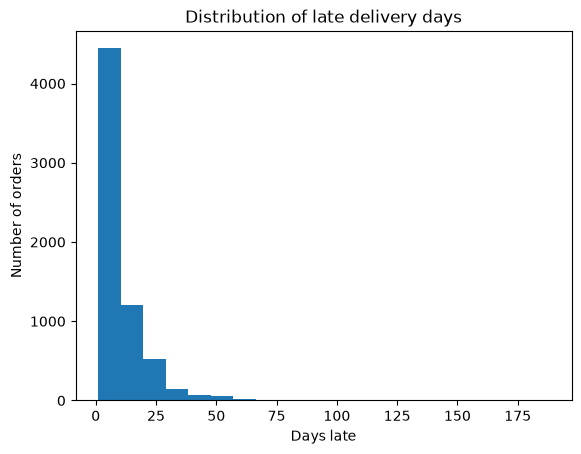

In [21]:
late_orders["delivery_difference"].plot(kind="hist", bins=20)
plt.title("Distribution of late delivery days")
plt.xlabel("Days late")
plt.ylabel("Number of orders")
plt.show()

In [22]:
monthly_delivery = pd.crosstab(
    delivered_orders["month"], delivered_orders["delivery_performance"])
monthly_delivery.head()

delivery_performance,Early,Late,On Time
month,,,
2016-09,0,1,0
2016-10,262,2,1
2016-12,1,0,0
2017-01,727,22,1
2017-02,1600,49,4


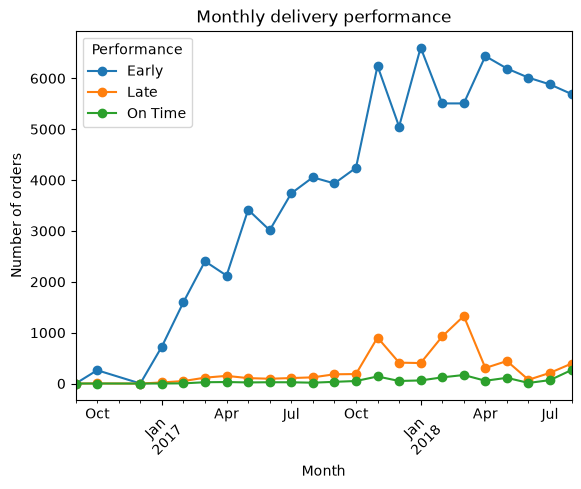

In [23]:
monthly_delivery.plot(kind="line", marker="o")
plt.title("Monthly delivery performance")
plt.xlabel("Month")
plt.ylabel("Number of orders")
plt.xticks(rotation=45)
plt.legend(title="Performance")
plt.show()

In [24]:
average_delivery_days = delivered_orders["delivery_days"].mean()
print("Average Delivery Days:", average_delivery_days)

Average Delivery Days: 12.09402923188556


In [25]:
delivery_days_group= pd.cut(
    delivered_orders["delivery_days"],
    bins= [0,5,10,15,20,30,100],
    labels= ["0-5","6-10","11-15","16-20","21-30","30+"])
delivery_days_group.value_counts().sort_index()

delivery_days
0-5      19225
6-10     32856
11-15    21166
16-20    10710
21-30     8382
30+       4055
Name: count, dtype: int64

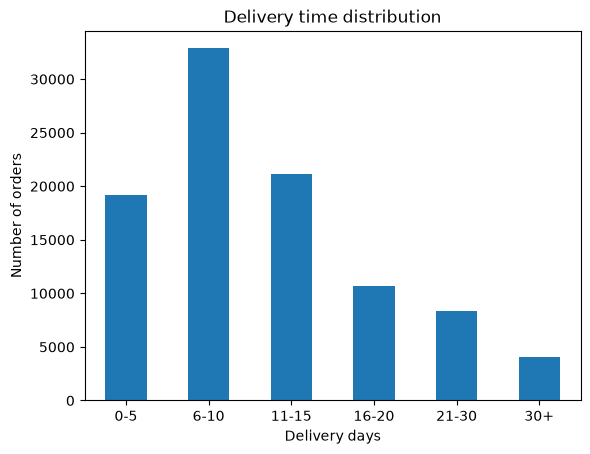

In [26]:
delivery_days_group.value_counts().sort_index().plot(kind="bar")
plt.title("Delivery time distribution")
plt.xlabel("Delivery days")
plt.ylabel("Number of orders")
plt.xticks(rotation=0)
plt.show()

In [27]:
print(orders.columns)

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'month', 'delivery_days', 'delivery_difference'],
      dtype='str')


## 4. Sales and Seller Analysis

In [28]:
order_items= pd.read_csv("olist_order_items_dataset.csv")
print(order_items.shape)

(112650, 7)


In [29]:
order_items.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='str')

In [30]:
total_sales= order_items["price"].sum()
print("Total product sales:", total_sales)

Total product sales: 13591643.7


In [31]:
total_freight = order_items["freight_value"].sum()
print("Total Freight Cost:", total_freight)

Total Freight Cost: 2251909.54


In [32]:
total_order_value= total_sales+ total_freight
print("Total order value", total_order_value)

Total order value 15843553.239999998


In [33]:
order_items["order_value"]= (order_items["price"] + order_items["freight_value"])
average_order_value = order_items["order_value"].mean()
print("Average order value:", average_order_value)

Average order value: 140.6440589436307


In [34]:
total_orders = order_items.groupby("order_id")["order_value"].sum()
aov = total_orders.mean()
print("Average order value:", aov)

Average order value: 160.57763809214924


In [35]:
sales_data = order_items.merge(
    orders[["order_id","month"]],
    on="order_id",
    how= "left")
monthly_sales= sales_data.groupby("month")["price"].sum()
monthly_sales

month
2016-09        267.36
2016-10      49507.66
2016-12         10.90
2017-01     120312.87
2017-02     247303.02
2017-03     374344.30
2017-04     359927.23
2017-05     506071.14
2017-06     433038.60
2017-07     498031.48
2017-08     573971.68
2017-09     624401.69
2017-10     664219.43
2017-11    1010271.37
2017-12     743914.17
2018-01     950030.36
2018-02     844178.71
2018-03     983213.44
2018-04     996647.75
2018-05     996517.68
2018-06     865124.31
2018-07     895507.22
2018-08     854686.33
2018-09        145.00
Freq: M, Name: price, dtype: float64

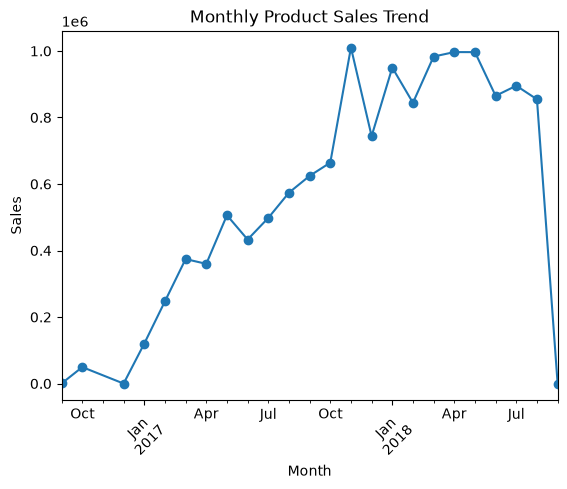

In [36]:
monthly_sales.plot(kind="line", marker="o")
plt.title("Monthly Product Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

In [37]:
monthly_freight = sales_data.groupby("month")["freight_value"].sum()

print(monthly_freight)

month
2016-09        87.39
2016-10      7301.18
2016-12         8.72
2017-01     16875.62
2017-02     38977.60
2017-03     57704.29
2017-04     52495.01
2017-05     80119.81
2017-06     69924.44
2017-07     86940.14
2017-08     94232.92
2017-09     95997.22
2017-10    105092.94
2017-11    168872.40
2017-12    119633.06
2018-01    157271.53
2018-02    142730.25
2018-03    171913.38
2018-04    163050.29
2018-05    153264.14
2018-06    157552.80
2018-07    163220.81
2018-08    148622.14
2018-09        21.46
Freq: M, Name: freight_value, dtype: float64


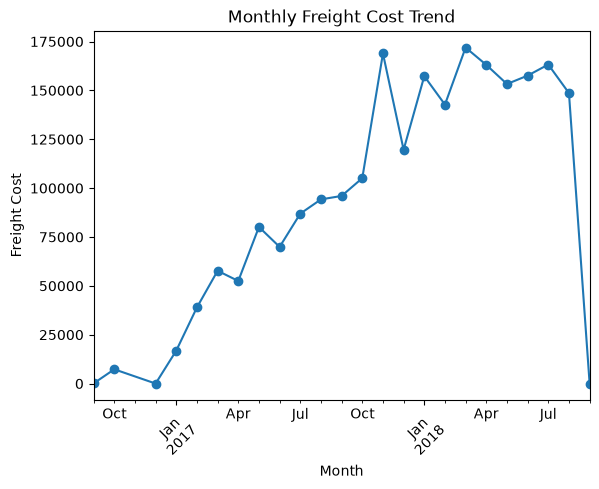

In [38]:
monthly_freight.plot(kind="line", marker="o")

plt.title("Monthly Freight Cost Trend")
plt.xlabel("Month")
plt.ylabel("Freight Cost")
plt.xticks(rotation=45)
plt.show()

In [39]:
seller_sales= (
    order_items.groupby("seller_id")["price"]
    .sum()
    .sort_values(ascending= False)
    .head(10))
print(seller_sales)

seller_id
4869f7a5dfa277a7dca6462dcf3b52b2    229472.63
53243585a1d6dc2643021fd1853d8905    222776.05
4a3ca9315b744ce9f8e9374361493884    200472.92
fa1c13f2614d7b5c4749cbc52fecda94    194042.03
7c67e1448b00f6e969d365cea6b010ab    187923.89
7e93a43ef30c4f03f38b393420bc753a    176431.87
da8622b14eb17ae2831f4ac5b9dab84a    160236.57
7a67c85e85bb2ce8582c35f2203ad736    141745.53
1025f0e2d44d7041d6cf58b6550e0bfa    138968.55
955fee9216a65b617aa5c0531780ce60    135171.70
Name: price, dtype: float64


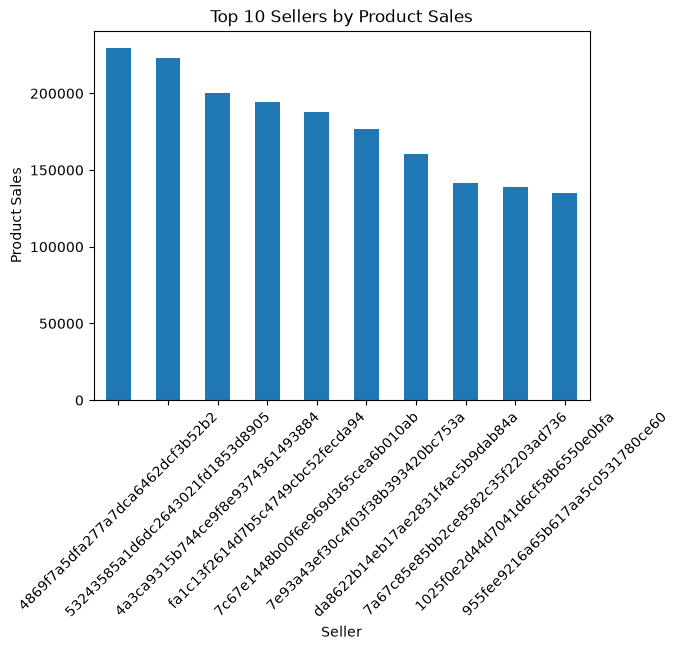

In [40]:
seller_sales.plot(kind="bar")

plt.title("Top 10 Sellers by Product Sales")
plt.xlabel("Seller")
plt.ylabel("Product Sales")
plt.xticks(rotation=45)
plt.show()

In [41]:
top_products = (order_items.groupby("product_id")["price"]
                .sum()
                .sort_values(ascending= False)
                .head(10))
print(top_products)

product_id
bb50f2e236e5eea0100680137654686c    63885.00
6cdd53843498f92890544667809f1595    54730.20
d6160fb7873f184099d9bc95e30376af    48899.34
d1c427060a0f73f6b889a5c7c61f2ac4    47214.51
99a4788cb24856965c36a24e339b6058    43025.56
3dd2a17168ec895c781a9191c1e95ad7    41082.60
25c38557cf793876c5abdd5931f922db    38907.32
5f504b3a1c75b73d6151be81eb05bdc9    37733.90
53b36df67ebb7c41585e8d54d6772e08    37683.42
aca2eb7d00ea1a7b8ebd4e68314663af    37608.90
Name: price, dtype: float64


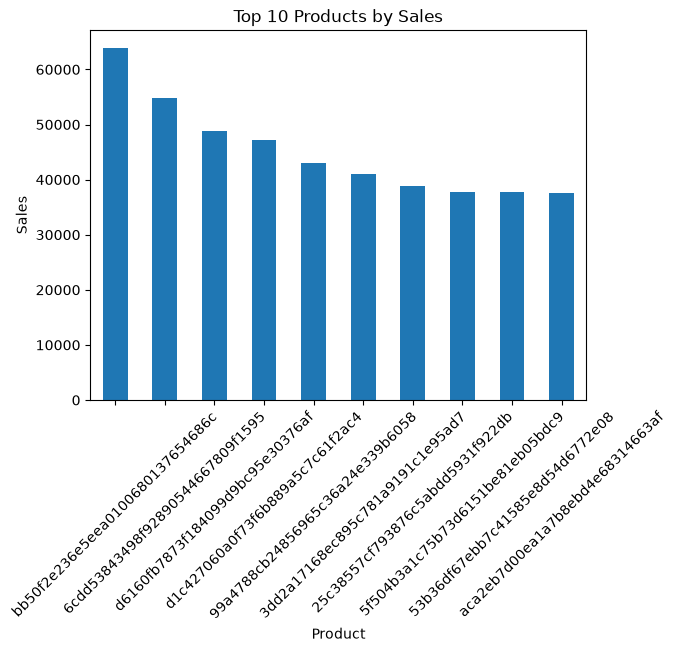

In [42]:
top_products.plot(kind="bar")
plt.title("Top 10 Products by Sales")
plt.xlabel("Product")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

In [43]:
seller_orders = (
    order_items.groupby("seller_id")["order_id"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

print(seller_orders)

seller_id
6560211a19b47992c3666cc44a7e94c0    1854
4a3ca9315b744ce9f8e9374361493884    1806
cc419e0650a3c5ba77189a1882b7556a    1706
1f50f920176fa81dab994f9023523100    1404
da8622b14eb17ae2831f4ac5b9dab84a    1314
955fee9216a65b617aa5c0531780ce60    1287
7a67c85e85bb2ce8582c35f2203ad736    1160
ea8482cd71df3c1969d7b9473ff13abc    1146
4869f7a5dfa277a7dca6462dcf3b52b2    1132
3d871de0142ce09b7081e2b9d1733cb1    1080
Name: order_id, dtype: int64


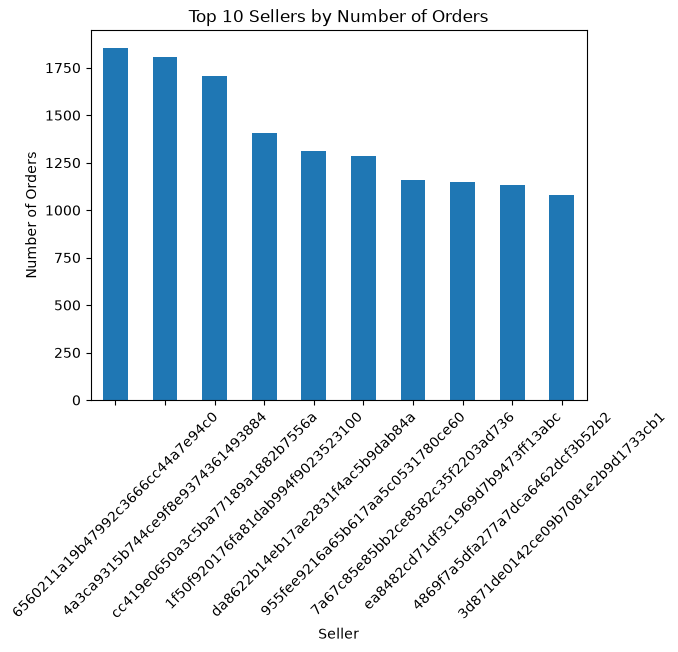

In [44]:
seller_orders.plot(kind="bar")

plt.title("Top 10 Sellers by Number of Orders")
plt.xlabel("Seller")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

In [45]:
monthly_aov = (
    sales_data.groupby("month")["order_value"]
    .sum()
    / sales_data.groupby("month")["order_id"].nunique()
)

print(monthly_aov)

month
2016-09    118.250000
2016-10    184.444286
2016-12     19.620000
2017-01    173.876413
2017-02    165.193664
2017-03    163.592802
2017-04    172.489435
2017-05    160.161462
2017-06    156.345365
2017-07    147.385140
2017-08    155.649802
2017-09    169.785272
2017-10    168.413391
2017-11    158.253090
2017-12    153.546805
2018-01    153.365913
2018-02    147.431873
2018-03    160.702117
2018-04    167.248059
2018-05    167.777881
2018-06    166.019011
2018-07    168.775391
2018-08    155.503483
2018-09    166.460000
Freq: M, dtype: float64


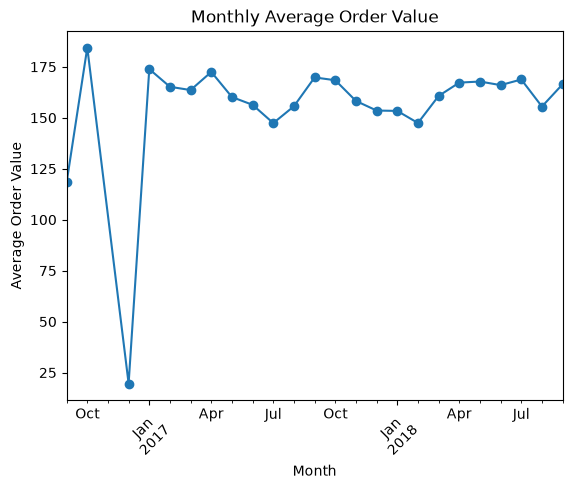

In [46]:
monthly_aov.plot(kind="line", marker="o")

plt.title("Monthly Average Order Value")
plt.xlabel("Month")
plt.ylabel("Average Order Value")
plt.xticks(rotation=45)
plt.show()

## 5. Customer, Payment and Review Analysis

In [47]:
payments = pd.read_csv("olist_order_payments_dataset.csv")

print(payments.shape)
print(payments.columns)

(103886, 5)
Index(['order_id', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value'],
      dtype='str')


In [48]:
payment_analysis = (
    payments.groupby("payment_type")["payment_value"]
    .agg(["count", "sum"])
    .sort_values("sum", ascending=False)
)

print(payment_analysis)

              count          sum
payment_type                    
credit_card   76795  12542084.19
boleto        19784   2869361.27
voucher        5775    379436.87
debit_card     1529    217989.79
not_defined       3         0.00


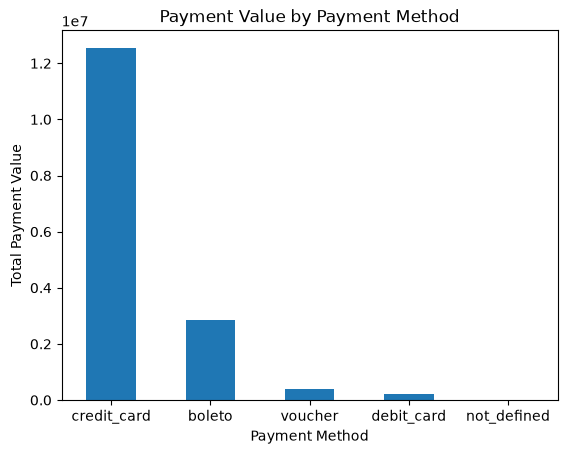

In [49]:
payment_analysis["sum"].plot(kind="bar")

plt.title("Payment Value by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Total Payment Value")
plt.xticks(rotation=0)
plt.show()

In [50]:
customers = pd.read_csv("olist_customers_dataset.csv")

print(customers.shape)
print(customers.columns)

(99441, 5)
Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='str')


In [51]:
customer_orders = orders.merge(
    customers[["customer_id", "customer_state"]],
    on="customer_id",
    how="left"
)

state_orders = (
    customer_orders.groupby("customer_state")["order_id"]
    .nunique()
    .sort_values(ascending=False)
)

print(state_orders)

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
PE     1652
CE     1336
PA      975
MT      907
MA      747
MS      715
PB      536
PI      495
RN      485
AL      413
SE      350
TO      280
RO      253
AM      148
AC       81
AP       68
RR       46
Name: order_id, dtype: int64


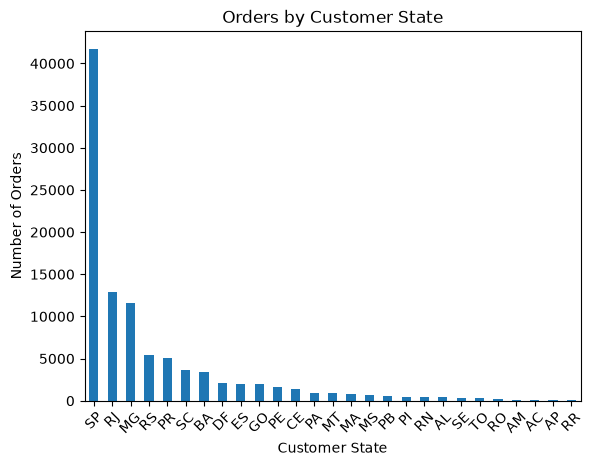

In [52]:
state_orders.plot(kind="bar")

plt.title("Orders by Customer State")
plt.xlabel("Customer State")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

In [53]:
reviews = pd.read_csv("olist_order_reviews_dataset.csv")

print(reviews.shape)
print(reviews.columns)

(99224, 7)
Index(['review_id', 'order_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp'],
      dtype='str')


In [54]:
review_scores = reviews["review_score"].value_counts().sort_index()

print(review_scores)

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64


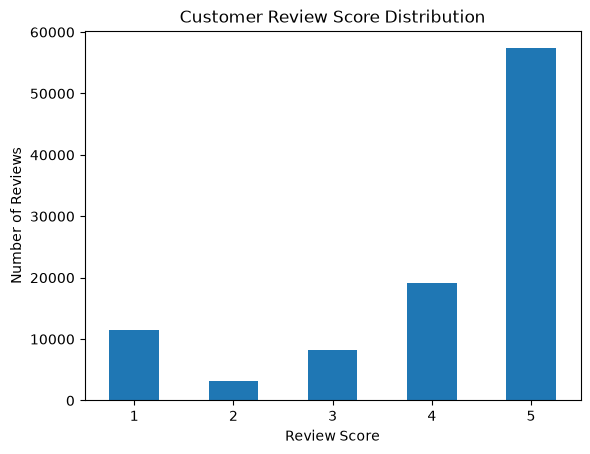

In [55]:
review_scores.plot(kind="bar")

plt.title("Customer Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

In [56]:
print("PYTHON PROJECT SUMMARY")
print("----------------------")
print("Total Orders:", len(orders))
print("Delivered Orders:", len(delivered_orders))
print("Average Delivery Days:", round(average_delivery_days, 2))
print("Late Orders:", len(late_orders))
print("Average Days Late:", round(late_orders["delivery_difference"].mean(), 2))
print("Total Product Sales:", round(total_sales, 2))
print("Total Freight Cost:", round(total_freight, 2))
print("Average Order Value:", round(aov, 2))

PYTHON PROJECT SUMMARY
----------------------
Total Orders: 99441
Delivered Orders: 96478
Average Delivery Days: 12.09
Late Orders: 6534
Average Days Late: 10.62
Total Product Sales: 13591643.7
Total Freight Cost: 2251909.54
Average Order Value: 160.58


## 6. Key Business Insights

### Order and Delivery

- The dataset contains 99,441 orders, of which 96,478 were delivered.
- The average delivery time for delivered orders was 12.09 days.
- There were 6,534 late deliveries.
- Late deliveries were 10.62 days late on average.
- The maximum recorded delay was 188 days.

### Sales and Revenue

- Total product sales were approximately 13.59 million.
- Total freight cost was approximately 2.25 million.
- The combined product and freight value was approximately 15.84 million.
- The average order value was approximately 160.58.
- Monthly sales showed an overall upward trend during the main period of the dataset.
- A small group of sellers and products accounted for a significant share of sales.

### Customer, Payment and Review Insights

- Credit card was the most widely used payment method and generated the highest payment value.
- Customer orders were concentrated in a smaller number of states, with a few states contributing a large share of total orders.
- Review scores were concentrated toward the higher ratings, with 5-star reviews being the most common.

## 7. Conclusion

This Python project demonstrates an end-to-end analysis of Olist e-commerce data. 
The analysis uses Pandas for data manipulation and Matplotlib for visualization 
to identify patterns in orders, sales, delivery performance, customers, payments, 
sellers, products, and reviews.

The findings provide a practical view of e-commerce performance and demonstrate 
how Python can be used to transform raw data into meaningful business insights.